# IMPORT LIBRARIES

In [27]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

print(f"TensorFlow version: {tf.__version__}")

TensorFlow version: 2.20.0


In [28]:
train_dir = "fruits-and-vegetables-images-hd/train"
test_dir  = "fruits-and-vegetables-images-hd/test"

for dirpath, dirnames, filenames in os.walk(train_dir):
    if len(filenames) > 0:
        print(f"There are {len(filenames)} images in '{dirpath}'.")

There are 256 images in 'fruits-and-vegetables-images-hd/train\apple'.
There are 227 images in 'fruits-and-vegetables-images-hd/train\brinjal'.
There are 224 images in 'fruits-and-vegetables-images-hd/train\capsicum'.
There are 288 images in 'fruits-and-vegetables-images-hd/train\carrot'.
There are 204 images in 'fruits-and-vegetables-images-hd/train\garlic'.
There are 253 images in 'fruits-and-vegetables-images-hd/train\ginger'.
There are 299 images in 'fruits-and-vegetables-images-hd/train\lady finger'.
There are 192 images in 'fruits-and-vegetables-images-hd/train\lemon'.
There are 272 images in 'fruits-and-vegetables-images-hd/train\onion'.
There are 241 images in 'fruits-and-vegetables-images-hd/train\potato'.
There are 272 images in 'fruits-and-vegetables-images-hd/train\tomato'.


## Load and Prepare the Data

In [29]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

train_data = tf.keras.preprocessing.image_dataset_from_directory(
    directory=train_dir,
    image_size=IMG_SIZE,
    label_mode="categorical",
    batch_size=BATCH_SIZE
)

test_data = tf.keras.preprocessing.image_dataset_from_directory(
    directory=test_dir,
    image_size=IMG_SIZE,
    label_mode="categorical",
    batch_size=BATCH_SIZE
)

Found 2711 files belonging to 11 classes.
Found 570 files belonging to 11 classes.


In [30]:
# Check the class names
class_names = train_data.class_names
print(f"Class names: {class_names}")
print(f"Number of classes: {len(class_names)}")

Class names: ['apple', 'brinjal', 'capsicum', 'carrot', 'garlic', 'ginger', 'lady finger', 'lemon', 'onion', 'potato', 'tomato']
Number of classes: 11


## Visualize Sample Images

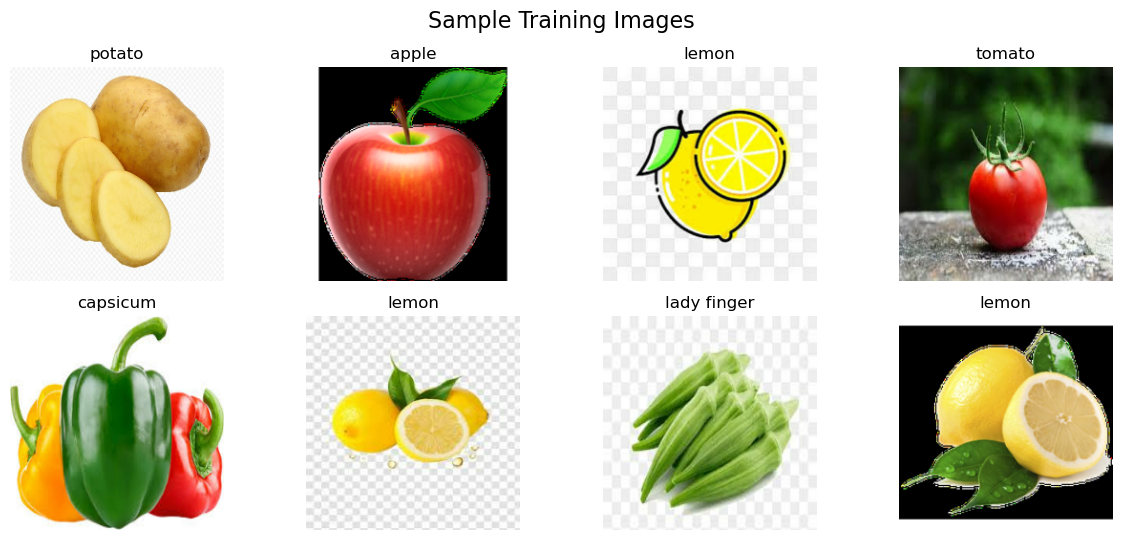

In [31]:
plt.figure(figsize=(12, 8))
for images, labels in train_data.take(1):
    for i in range(8):
        ax = plt.subplot(3, 4, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[tf.argmax(labels[i]).numpy()])
        plt.axis("off")
plt.suptitle("Sample Training Images", fontsize=16)
plt.tight_layout()
plt.show()

## Create Data Augmentation Layer

In [32]:
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),      
    layers.RandomRotation(0.2),          
    layers.RandomZoom(0.2),                
    layers.RandomHeight(0.2),              
    layers.RandomWidth(0.2),                
], name="data_augmentation")

print("Data augmentation layer created!")

Data augmentation layer created!


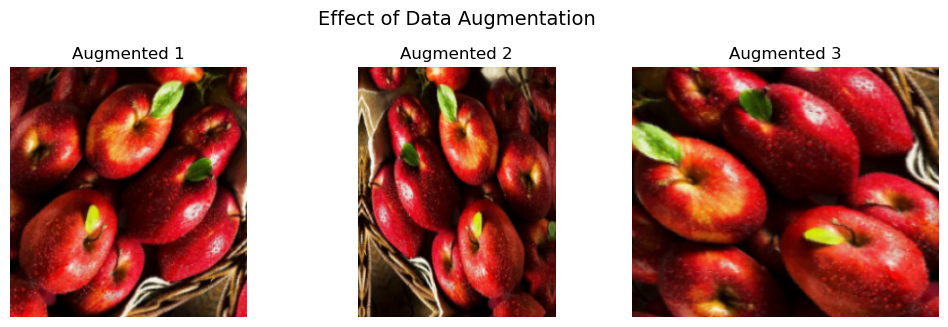

In [33]:
plt.figure(figsize=(10, 6))
for images, _ in train_data.take(1):
    sample_image = images[0]
    for i in range(3):
        augmented = data_augmentation(tf.expand_dims(sample_image, axis=0))
        ax = plt.subplot(2, 3, i + 1)
        plt.imshow(tf.squeeze(augmented).numpy().astype("uint8"))
        plt.title(f"Augmented {i+1}")
        plt.axis("off")
plt.suptitle("Effect of Data Augmentation", fontsize=14)
plt.tight_layout()
plt.show()

## Helper Functions

In [34]:
def plot_loss_curves(history):
    """
    Returns separate loss curves for training and validation metrics.
    """
    loss = history.history["loss"]
    val_loss = history.history["val_loss"]

    accuracy = history.history["accuracy"]
    val_accuracy = history.history["val_accuracy"]

    epochs = range(len(loss))

    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)
    plt.plot(epochs, loss, label="training_loss")
    plt.plot(epochs, val_loss, label="val_loss")
    plt.title("Loss")
    plt.xlabel("Epochs")
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(epochs, accuracy, label="training_accuracy")
    plt.plot(epochs, val_accuracy, label="val_accuracy")
    plt.title("Accuracy")
    plt.xlabel("Epochs")
    plt.legend()

    plt.tight_layout()
    plt.show()

In [35]:
def compare_historys(original_history, new_history, initial_epochs=5):
    """
    Compares two model history objects (before and after fine-tuning).
    """
    acc     = original_history.history["accuracy"]
    loss    = original_history.history["loss"]
    val_acc  = original_history.history["val_accuracy"]
    val_loss = original_history.history["val_loss"]

    total_acc     = acc     + new_history.history["accuracy"]
    total_loss    = loss    + new_history.history["loss"]
    total_val_acc  = val_acc  + new_history.history["val_accuracy"]
    total_val_loss = val_loss + new_history.history["val_loss"]

    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)
    plt.plot(total_acc, label="training_accuracy")
    plt.plot(total_val_acc, label="val_accuracy")
    plt.axvline(x=initial_epochs - 1, color="red", linestyle="--", label="Start Fine-Tuning")
    plt.title("Training vs Validation Accuracy")
    plt.xlabel("Epochs")
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(total_loss, label="training_loss")
    plt.plot(total_val_loss, label="val_loss")
    plt.axvline(x=initial_epochs - 1, color="red", linestyle="--", label="Start Fine-Tuning")
    plt.title("Training vs Validation Loss")
    plt.xlabel("Epochs")
    plt.legend()

    plt.tight_layout()
    plt.show()

## Setup Callbacks

In [36]:
import datetime

def create_tensorboard_callback(dir_name, experiment_name):
    """
    Creates a TensorBoard callback to log model training metrics.
    """
    log_dir = dir_name + "/" + experiment_name + "/" + datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
    tensorboard_callback = tf.keras.callbacks.TensorBoard(log_dir=log_dir)
    print(f"Saving TensorBoard log files to: {log_dir}")
    return tensorboard_callback

In [37]:
checkpoint_path = "model_checkpoints/checkpoint.weights.h5"

checkpoint_callback = tf.keras.callbacks.ModelCheckpoint(
    filepath=checkpoint_path,
    save_weights_only=True,  
    save_best_only=True,     
    save_freq="epoch",       
    verbose=1
)

print(f"Model weights will be saved to: {checkpoint_path}")

Model weights will be saved to: model_checkpoints/checkpoint.weights.h5


## Build the Model (Feature Extraction)

In [38]:
import tensorflow as tf
from tensorflow.keras import layers

# 1. Clear session again just to be safe
tf.keras.backend.clear_session()

# 2. Build the model architecture WITHOUT weights first.
# This avoids the immediate crash during initialization.
base_model = tf.keras.applications.EfficientNetB0(
    include_top=False,
    weights=None, 
    input_shape=(224, 224, 3)
)

# 3. Now, try to load the weights separately. 
# If this fails, your downloaded weight file is definitely corrupted.
try:
    # This downloads/links the official ImageNet weights
    weights_path = tf.keras.utils.get_file(
        "efficientnetb0_notop.h5",
        "https://storage.googleapis.com/keras-applications/efficientnetb0_notop.h5",
        cache_subdir="models"
    )
    base_model.load_weights(weights_path)
    print("Weights loaded successfully!")
except Exception as e:
    print(f"Manual weight loading failed: {e}")

# 4. Proceed with your functional model
base_model.trainable = False
inputs = layers.Input(shape=(224, 224, 3), name="input_layer")
x = data_augmentation(inputs)
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D(name="global_average_pooling_layer")(x)
outputs = layers.Dense(len(class_names), activation="softmax", name="output_layer")(x)

model = tf.keras.Model(inputs, outputs)


Weights loaded successfully!


In [39]:
model.compile(
    loss="categorical_crossentropy",
    optimizer=tf.keras.optimizers.Adam(),
    metrics=["accuracy"]
)

In [40]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, None, None, 3)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, None, None,     │     4,049,571 │
│                                 │ 1280)                  │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling_layer    │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 11)             │        14,091 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,063,662 (15.50 MB)

 Trainable params: 14,091 (55.04 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

## Train the Model — Feature Extraction

In [41]:
initial_epochs = 5

history_feature_extraction = model.fit(
    train_data,
    epochs=initial_epochs,
    validation_data=test_data,
    validation_steps=int(0.25 * len(test_data)), 
    callbacks=[
        create_tensorboard_callback("transfer_learning", "feature_extraction"),
        checkpoint_callback
    ]
)

Saving TensorBoard log files to: transfer_learning/feature_extraction/20260308-120512
Epoch 1/5
85/85 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.5270 - loss: 1.6242
Epoch 1: val_loss improved from None to 0.52015, saving model to model_checkpoints/checkpoint.weights.h5
85/85 ━━━━━━━━━━━━━━━━━━━━ 150s 2s/step - accuracy: 0.7344 - loss: 1.0764 - val_accuracy: 0.8672 - val_loss: 0.5202
Epoch 2/5
85/85 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9304 - loss: 0.4164
Epoch 2: val_loss improved from 0.52015 to 0.27757, saving model to model_checkpoints/checkpoint.weights.h5
85/85 ━━━━━━━━━━━━━━━━━━━━ 129s 2s/step - accuracy: 0.9332 - loss: 0.3677 - val_accuracy: 0.9375 - val_loss: 0.2776
Epoch 3/5
85/85 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9459 - loss: 0.2753
Epoch 3: val_loss improved from 0.27757 to 0.20159, saving model to model_checkpoints/checkpoint.weights.h5
85/85 ━━━━━━━━━━━━━━━━━━━━ 137s 1s/step - accuracy: 0.9484 - loss: 0.2594 - val_accuracy: 0.9453 - val_loss: 0.2016

In [42]:
print("Evaluating fine-tuned model on test data...")
results_fine_tuning = model.evaluate(test_data)
print(f"\nTest Loss: {results_fine_tuning[0]:.4f}")
print(f"Test Accuracy: {results_fine_tuning[1]:.4f}")

Evaluating fine-tuned model on test data...
18/18 ━━━━━━━━━━━━━━━━━━━━ 26s 1s/step - accuracy: 0.9368 - loss: 0.2120

Test Loss: 0.2120
Test Accuracy: 0.9368


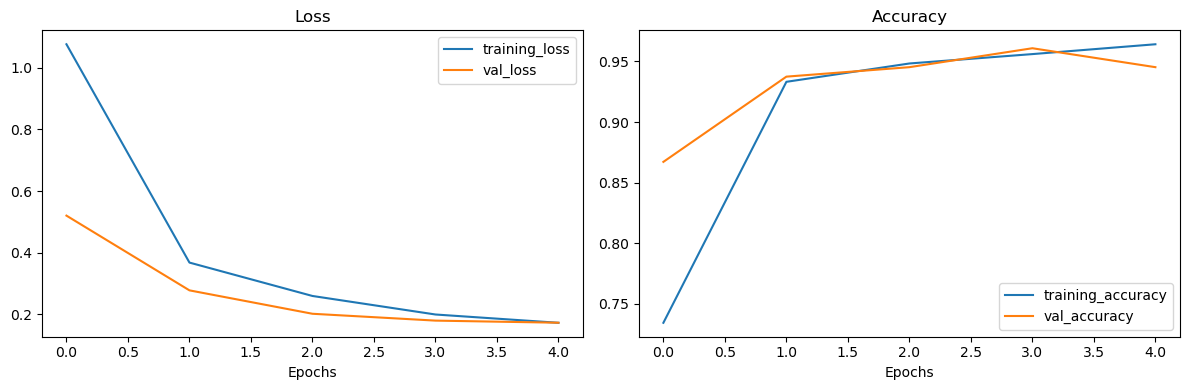

In [43]:
plot_loss_curves(history_feature_extraction)

In [44]:
base_model_layer = model.layers[2]

base_model_layer.trainable = True

for layer in base_model_layer.layers[:-10]:
    layer.trainable = False

print(f"Number of trainable variables: {len(model.trainable_variables)}")

Number of trainable variables: 12


In [45]:
for layer_number, layer in enumerate(base_model_layer.layers):
    print(layer_number, layer.name, layer.trainable)

0 input_layer False
1 rescaling False
2 normalization False
3 stem_conv_pad False
4 stem_conv False
5 stem_bn False
6 stem_activation False
7 block1a_dwconv False
8 block1a_bn False
9 block1a_activation False
10 block1a_se_squeeze False
11 block1a_se_reshape False
12 block1a_se_reduce False
13 block1a_se_expand False
14 block1a_se_excite False
15 block1a_project_conv False
16 block1a_project_bn False
17 block2a_expand_conv False
18 block2a_expand_bn False
19 block2a_expand_activation False
20 block2a_dwconv_pad False
21 block2a_dwconv False
22 block2a_bn False
23 block2a_activation False
24 block2a_se_squeeze False
25 block2a_se_reshape False
26 block2a_se_reduce False
27 block2a_se_expand False
28 block2a_se_excite False
29 block2a_project_conv False
30 block2a_project_bn False
31 block2b_expand_conv False
32 block2b_expand_bn False
33 block2b_expand_activation False
34 block2b_dwconv False
35 block2b_bn False
36 block2b_activation False
37 block2b_se_squeeze False
38 block2b_se_resha

In [46]:
model.compile(
    loss="categorical_crossentropy",
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),  # 10x lower than before
    metrics=["accuracy"]
)

In [47]:
fine_tune_epochs = initial_epochs + 5

history_fine_tuning = model.fit(
    train_data,
    epochs=fine_tune_epochs,
    initial_epoch=history_feature_extraction.epoch[-1], 
    validation_data=test_data,
    validation_steps=int(0.25 * len(test_data)),
    callbacks=[
        create_tensorboard_callback("transfer_learning", "fine_tuning")
    ]
)

Saving TensorBoard log files to: transfer_learning/fine_tuning/20260308-121711
Epoch 5/10
85/85 ━━━━━━━━━━━━━━━━━━━━ 157s 2s/step - accuracy: 0.9609 - loss: 0.1723 - val_accuracy: 0.9297 - val_loss: 0.1842
Epoch 6/10
85/85 ━━━━━━━━━━━━━━━━━━━━ 132s 2s/step - accuracy: 0.9712 - loss: 0.1135 - val_accuracy: 0.9688 - val_loss: 0.0809
Epoch 7/10
85/85 ━━━━━━━━━━━━━━━━━━━━ 131s 2s/step - accuracy: 0.9819 - loss: 0.0868 - val_accuracy: 0.9688 - val_loss: 0.1004
Epoch 8/10
85/85 ━━━━━━━━━━━━━━━━━━━━ 133s 2s/step - accuracy: 0.9841 - loss: 0.0733 - val_accuracy: 0.9688 - val_loss: 0.0775
Epoch 9/10
85/85 ━━━━━━━━━━━━━━━━━━━━ 133s 2s/step - accuracy: 0.9878 - loss: 0.0662 - val_accuracy: 0.9766 - val_loss: 0.0754
Epoch 10/10
85/85 ━━━━━━━━━━━━━━━━━━━━ 138s 2s/step - accuracy: 0.9904 - loss: 0.0505 - val_accuracy: 0.9531 - val_loss: 0.1144


In [48]:
print("Evaluating fine-tuned model on test data...")
results_fine_tuning = model.evaluate(test_data)
print(f"\nTest Loss: {results_fine_tuning[0]:.4f}")
print(f"Test Accuracy: {results_fine_tuning[1]:.4f}")

Evaluating fine-tuned model on test data...
18/18 ━━━━━━━━━━━━━━━━━━━━ 25s 1s/step - accuracy: 0.9579 - loss: 0.1405

Test Loss: 0.1405
Test Accuracy: 0.9579


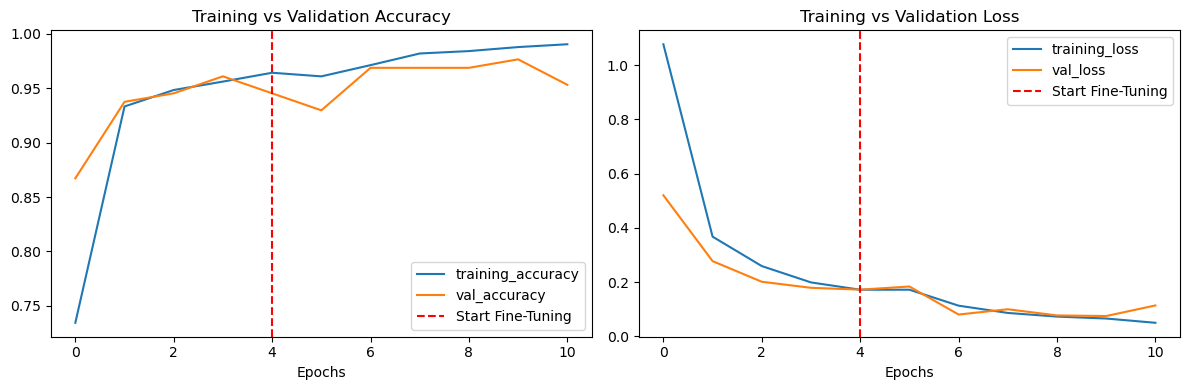

In [49]:
compare_historys(
    original_history=history_feature_extraction,
    new_history=history_fine_tuning,
    initial_epochs=initial_epochs
)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


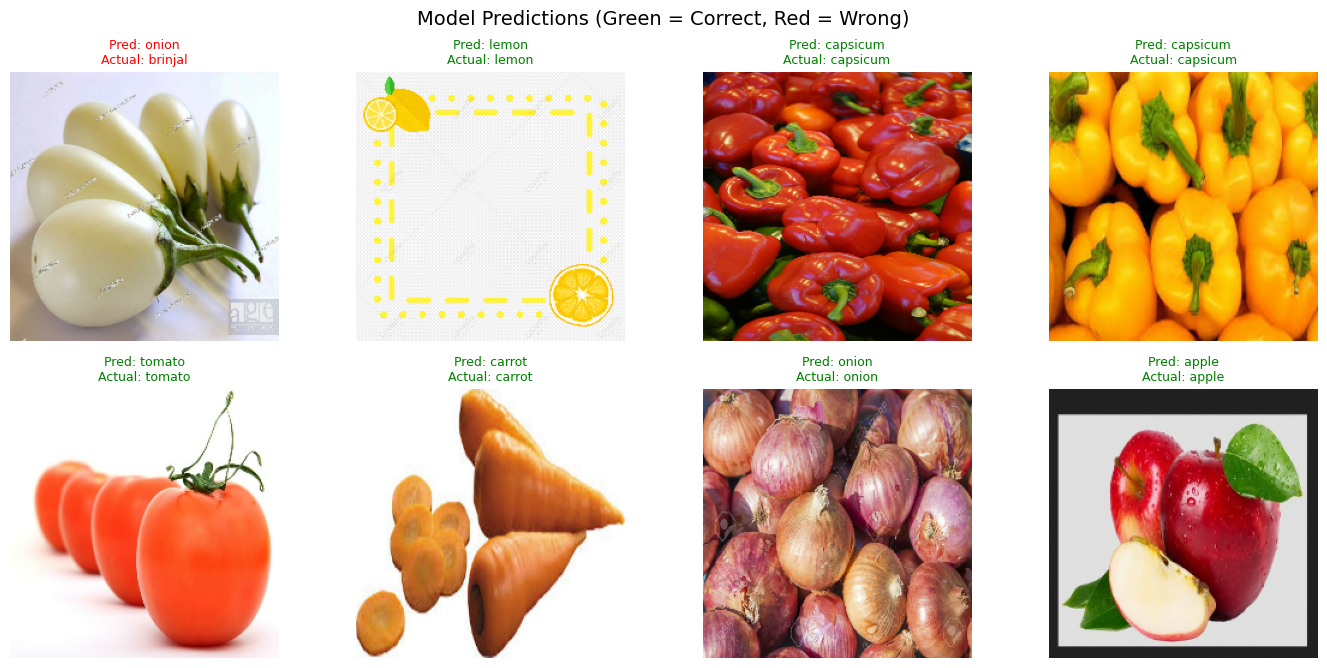

In [52]:
plt.figure(figsize=(14, 10))

for images, labels in test_data.take(1):
    predictions = model.predict(images)

    for i in range(8):
        ax = plt.subplot(3, 4, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))

        predicted_class = class_names[tf.argmax(predictions[i]).numpy()]
        actual_class = class_names[tf.argmax(labels[i]).numpy()]

        color = "green" if predicted_class == actual_class else "red"
        plt.title(f"Pred: {predicted_class}\nActual: {actual_class}", color=color, fontsize=9)
        plt.axis("off")

plt.suptitle("Model Predictions (Green = Correct, Red = Wrong)", fontsize=14)
plt.tight_layout()
plt.show()